In [1]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses, optimizers, callbacks
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置随机种子 (Reproducibility)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. 读取上一阶段保存的数据
data_path = "../data/modeling_data_ready.pkl"
try:
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    print("✅ 数据加载成功！")
except FileNotFoundError:
    print("❌ 错误：未找到数据文件，请检查路径。")

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

# 同时也读取 SMOTE 数据（用于后续的对比基准模型，SDAE主要用原始数据）
X_train_smote = data['X_train_smote']
y_train_smote = data['y_train_smote']

# 获取输入维度
input_dim = X_train.shape[1]
print(f"输入特征维度: {input_dim}")
print(f"训练集形状: {X_train.shape}")

e:\miniconda3\envs\GradProject\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


✅ 数据加载成功！
输入特征维度: 15
训练集形状: (4929, 15)


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

# 假设数据已加载
# X_train, X_val ...

INPUT_DIM = X_train.shape[1]
HIDDEN_UNITS = [12, 10, 8] 

def train_and_evaluate_layer(X_in, layer_idx, hidden_units):
    """训练单层并进行深度体检"""
    input_dim = X_in.shape[1]
    print(f"\n>>> 正在训练第 {layer_idx} 层: {input_dim} -> {hidden_units}")
    
    # 1. 建网
    input_layer = layers.Input(shape=(input_dim,))
    # 稍微降低一点噪声，看看是不是噪声太大导致学不会
    masked = layers.Dropout(0.1)(input_layer) 
    
    # 给 Dense 层命名，方便提取权重
    dense_name = f"encoder_dense_{layer_idx}"
    encoded = layers.Dense(hidden_units, activation='selu', 
                           activity_regularizer=regularizers.l1(1e-5),
                           name=dense_name)(masked)
    
    decoded = layers.Dense(input_dim, activation='linear')(encoded)
    
    autoencoder = keras.Model(inputs=input_layer, outputs=decoded)
    encoder = keras.Model(inputs=input_layer, outputs=encoded)
    
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # 2. 训练
    history = autoencoder.fit(
        X_in, X_in, 
        epochs=40, 
        batch_size=64, 
        verbose=0,
        validation_split=0.1
    )
    
    # 3. 质量检查 (Checkpoints)
    final_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    
    # 检查特征是否有活性
    latent_features = encoder.predict(X_in, verbose=0)
    feature_std = np.std(latent_features)
    feature_mean = np.mean(latent_features)
    dead_neurons = np.sum(np.var(latent_features, axis=0) < 1e-4)
    
    print(f"  [指标] Train Loss: {final_loss:.5f} | Val Loss: {val_loss:.5f}")
    print(f"  [活性] 特征标准差: {feature_std:.4f} (如果<0.01说明特征坍塌)")
    print(f"  [死区] 失活神经元数: {dead_neurons}/{hidden_units}")
    
    if feature_std < 0.01 or dead_neurons > hidden_units/2:
        print("  ❌ 警告：这一层看起来没学到东西！(特征坍塌)")
    else:
        print("  ✅ 这一层看起来很健康。")
        
    return encoder, latent_features

# --- 执行第一阶段 ---
current_input = X_train
trained_encoders = []

for i, units in enumerate(HIDDEN_UNITS):
    encoder, current_input = train_and_evaluate_layer(current_input, i+1, units)
    trained_encoders.append(encoder)

print("\n=== 第一阶段完成：特征提取器就绪 ===")


>>> 正在训练第 1 层: 15 -> 12
  [指标] Train Loss: 0.06756 | Val Loss: 0.03099
  [活性] 特征标准差: 0.7650 (如果<0.01说明特征坍塌)
  [死区] 失活神经元数: 0/12
  ✅ 这一层看起来很健康。

>>> 正在训练第 2 层: 12 -> 10
  [指标] Train Loss: 0.05712 | Val Loss: 0.02597
  [活性] 特征标准差: 0.7191 (如果<0.01说明特征坍塌)
  [死区] 失活神经元数: 0/10
  ✅ 这一层看起来很健康。

>>> 正在训练第 3 层: 10 -> 8
  [指标] Train Loss: 0.04775 | Val Loss: 0.02027
  [活性] 特征标准差: 0.6796 (如果<0.01说明特征坍塌)
  [死区] 失活神经元数: 0/8
  ✅ 这一层看起来很健康。

=== 第一阶段完成：特征提取器就绪 ===


>>> 正在逐层提取 SDAE 特征...
  正在通过第 1 层编码器...
  正在通过第 2 层编码器...
  正在通过第 3 层编码器...
✅ 特征提取完成，最终维度: (705, 8)
原始数据中，第 3 列特征区分度似乎最大。


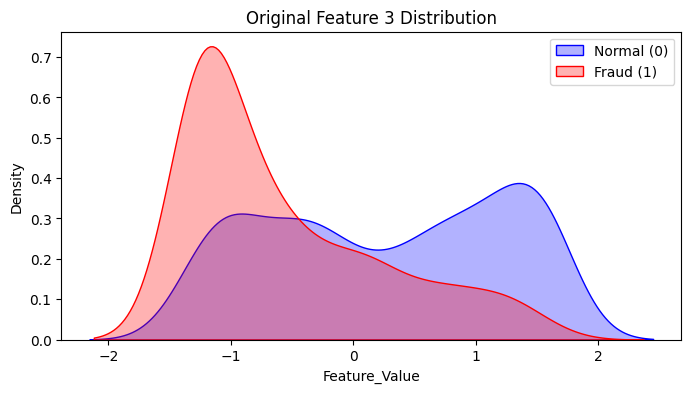

SDAE 特征中，第 6 个特征区分度似乎最大。


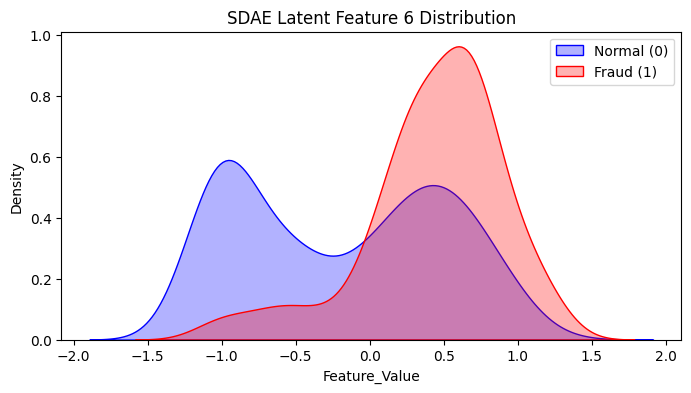


Latent 特征的方差 (如果接近0说明神经元死了):
[0.6467458  0.12676784 0.46725667 0.14655417 0.18778507 0.46156973
 0.4923046  0.5144776 ]


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print(">>> 正在逐层提取 SDAE 特征...")

# 1. 逐层传递数据 (Pipeline)
# X_test (15) -> Enc1 -> (12) -> Enc2 -> (10) -> Enc3 -> (8)
current_data = X_test
for i, enc in enumerate(trained_encoders):
    print(f"  正在通过第 {i+1} 层编码器...")
    current_data = enc.predict(current_data, verbose=0)

X_test_encoded = current_data # 这就是最终的 8维 Latent 特征
print(f"✅ 特征提取完成，最终维度: {X_test_encoded.shape}")

# 2. 对比：原始数据的特征分布 vs SDAE 特征分布
def plot_distribution_comparison(X_data, y_data, feature_index, title):
    # 确保是 numpy array
    if hasattr(X_data, 'values'):
        X_data = X_data.values
        
    df_plot = pd.DataFrame({
        'Feature_Value': X_data[:, feature_index],
        'Label': y_data
    })
    
    plt.figure(figsize=(8, 4))
    # 画正常样本 (Label 0)
    sns.kdeplot(data=df_plot[df_plot['Label']==0], x='Feature_Value', 
                label='Normal (0)', fill=True, color='blue', alpha=0.3)
    # 画欺诈样本 (Label 1)
    sns.kdeplot(data=df_plot[df_plot['Label']==1], x='Feature_Value', 
                label='Fraud (1)', fill=True, color='red', alpha=0.3)
    
    plt.title(title)
    plt.legend()
    plt.show()

# --- 画图 1: 原始数据中区分度最好的特征 ---
# 简单找均值差异最大的
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
mean_diff = np.abs(np.mean(X_test_np[y_test==0], axis=0) - np.mean(X_test_np[y_test==1], axis=0))
best_orig_idx = np.argmax(mean_diff)
print(f"原始数据中，第 {best_orig_idx} 列特征区分度似乎最大。")

plot_distribution_comparison(X_test_np, y_test, best_orig_idx, 
                             f"Original Feature {best_orig_idx} Distribution")

# --- 画图 2: SDAE 提取的特征 ---
# 同样找均值差异最大的
mean_diff_enc = np.abs(np.mean(X_test_encoded[y_test==0], axis=0) - np.mean(X_test_encoded[y_test==1], axis=0))
best_enc_idx = np.argmax(mean_diff_enc)
print(f"SDAE 特征中，第 {best_enc_idx} 个特征区分度似乎最大。")

plot_distribution_comparison(X_test_encoded, y_test, best_enc_idx, 
                             f"SDAE Latent Feature {best_enc_idx} Distribution")

# --- 检查死神经元 ---
variance = np.var(X_test_encoded, axis=0)
print("\nLatent 特征的方差 (如果接近0说明神经元死了):")
print(variance)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

print("=== 层级特征能力诊断 (Layer-wise Probing) ===")

# 1. 准备数据容器
layer_data = {
    'Original (15 dim)': (X_train, X_test)
}

# 2. 提取每一层的特征
current_train = X_train
current_test = X_test

for i, enc in enumerate(trained_encoders):
    print(f"提取第 {i+1} 层特征...", end="\r")
    # 逐层传递
    current_train = enc.predict(current_train, verbose=0)
    current_test = enc.predict(current_test, verbose=0)
    
    layer_name = f"Layer {i+1} ({HIDDEN_UNITS[i]} dim)"
    layer_data[layer_name] = (current_train, current_test)

print("\n\n=== 开始诊断每一层的分类能力 ===")
print(f"{'Layer Name':<20} | {'LR AUC':<10} | {'RF AUC':<10} | {'结论'}")
print("-" * 60)

for name, (X_tr, X_te) in layer_data.items():
    # A. 线性探针 (Logistic Regression) - 测试特征是否线性可分
    lr = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
    lr.fit(X_tr, y_train)
    lr_pred = lr.predict_proba(X_te)[:, 1]
    lr_auc = roc_auc_score(y_test, lr_pred)
    
    # B. 非线性探针 (Random Forest) - 测试特征的纯度
    rf = RandomForestClassifier(n_estimators=50, max_depth=5, class_weight='balanced', random_state=42)
    rf.fit(X_tr, y_train)
    rf_pred = rf.predict_proba(X_te)[:, 1]
    rf_auc = roc_auc_score(y_test, rf_pred)
    
    # 简单的评价
    conclusion = "基准" if "Original" in name else ""
    if "Original" not in name:
        if rf_auc > 0.85: conclusion = "🔥 强力"
        elif rf_auc > 0.80: conclusion = "✅ 有效"
        else: conclusion = "⚠️ 信息丢失"
        
    print(f"{name:<20} | {lr_auc:.4f}     | {rf_auc:.4f}     | {conclusion}")

=== 层级特征能力诊断 (Layer-wise Probing) ===
提取第 3 层特征...

=== 开始诊断每一层的分类能力 ===
Layer Name           | LR AUC     | RF AUC     | 结论
------------------------------------------------------------
Original (15 dim)    | 0.8570     | 0.8612     | 基准
Layer 1 (12 dim)     | 0.8509     | 0.8501     | 🔥 强力
Layer 2 (10 dim)     | 0.8481     | 0.8475     | ✅ 有效
Layer 3 (8 dim)      | 0.8489     | 0.8402     | ✅ 有效


In [15]:
from sklearn.utils import shuffle  # <--- 补上了这个
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== CSDE 最终集成 (Bagging + Layer-wise Voting) ===")

# 1. 准备数据
X_maj = X_train[y_train == 0]
X_min = X_train[y_train == 1]
y_min = y_train[y_train == 1]

# Bagging 设置
n_bags = 5 
ensemble_models = []

def get_base_classifier():
    return LogisticRegression(solver='liblinear', C=1.0, random_state=42)

# --- 训练阶段 ---
for t in range(n_bags):
    print(f"正在训练 Bag {t+1}/{n_bags}...", end="\r")
    
    # 1. 下采样多数类
    X_maj_sample = shuffle(X_maj, random_state=t)[:len(X_min)]
    
    X_batch = np.concatenate([X_maj_sample, X_min])
    y_batch = np.concatenate([np.zeros(len(X_min)), y_min])
    X_batch, y_batch = shuffle(X_batch, y_batch, random_state=t)
    
    # 2. 逐层提取特征并训练
    current_train_features = X_batch
    
    for layer_idx, enc in enumerate(trained_encoders):
        # 逐层传递
        current_train_features = enc.predict(current_train_features, verbose=0)
        
        clf = get_base_classifier()
        clf.fit(current_train_features, y_batch)
        
        ensemble_models.append({
            'model': clf,
            'layer_idx': layer_idx,
            'bag_idx': t
        })

print(f"\n✅ CSDE 训练完成，共集成 {len(ensemble_models)} 个基分类器。")

# --- 预测与评估阶段 ---
print("正在进行集成预测...")

# 预计算测试集特征
test_features_map = {}
current_test_features = X_test
for layer_idx, enc in enumerate(trained_encoders):
    current_test_features = enc.predict(current_test_features, verbose=0)
    test_features_map[layer_idx] = current_test_features

# 投票
y_pred_total = np.zeros(len(y_test))
for item in ensemble_models:
    layer_idx = item['layer_idx']
    clf = item['model']
    X_test_layer = test_features_map[layer_idx]
    pred = clf.predict_proba(X_test_layer)[:, 1]
    y_pred_total += pred

y_pred_avg = y_pred_total / len(ensemble_models)
csde_auc = roc_auc_score(y_test, y_pred_avg)

# 寻找最佳 F1 阈值
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    y_bin = (y_pred_avg > thresh).astype(int)
    f1 = f1_score(y_test, y_bin)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_final_class = (y_pred_avg > best_thresh).astype(int)

print(f"CSDE Ensemble AUC: {csde_auc:.4f}")
print(f"Best Threshold: {best_thresh:.2f}")
print(classification_report(y_test, y_final_class))


=== CSDE 最终集成 (Bagging + Layer-wise Voting) ===
正在训练 Bag 5/5...
✅ CSDE 训练完成，共集成 15 个基分类器。
正在进行集成预测...
CSDE Ensemble AUC: 0.8505
Best Threshold: 0.60
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       518
           1       0.59      0.71      0.64       187

    accuracy                           0.79       705
   macro avg       0.74      0.77      0.75       705
weighted avg       0.81      0.79      0.80       705



In [18]:
from imblearn.over_sampling import SMOTE, ADASYN

# --- 改进的训练阶段 ---
for t in range(n_bags):
    print(f"正在训练 Bag {t+1}/{n_bags}...", end="\r")
    
    # 策略变更：不再丢弃多数类，而是对少数类进行 SMOTE
    # 注意：这里我们使用 bootstrap 采样，或者简单地对训练集做 SMOTE
    
    # 1. 简单重采样 (Bootstrap)
    X_train_resampled, y_train_resampled = shuffle(X_train, y_train, random_state=t)
    
    # 2. 应用 SMOTE (仅在训练数据上！)
    # sampling_strategy=0.5 表示将少数类补充到多数类数量的 50%，或者 'auto' 补充到 1:1
    sm = SMOTE(sampling_strategy='auto', random_state=t) 
    X_batch, y_batch = sm.fit_resample(X_train_resampled, y_train_resampled)
    
    # 2. 逐层提取特征并训练 (保持不变)
    current_train_features = X_batch
    for layer_idx, enc in enumerate(trained_encoders):
        current_train_features = enc.predict(current_train_features, verbose=0)
        
        clf = get_base_classifier()
        clf.fit(current_train_features, y_batch) # 现在这是基于 SMOTE 后的平衡数据训练的
        
        ensemble_models.append({
            'model': clf,
            'layer_idx': layer_idx,
            'bag_idx': t
        })
        
print(f"\n✅ CSDE 训练完成，共集成 {len(ensemble_models)} 个基分类器。")

# --- 预测与评估阶段 ---
print("正在进行集成预测...")

# 预计算测试集特征
test_features_map = {}
current_test_features = X_test
for layer_idx, enc in enumerate(trained_encoders):
    current_test_features = enc.predict(current_test_features, verbose=0)
    test_features_map[layer_idx] = current_test_features

# 投票
y_pred_total = np.zeros(len(y_test))
for item in ensemble_models:
    layer_idx = item['layer_idx']
    clf = item['model']
    X_test_layer = test_features_map[layer_idx]
    pred = clf.predict_proba(X_test_layer)[:, 1]
    y_pred_total += pred

y_pred_avg = y_pred_total / len(ensemble_models)
csde_auc = roc_auc_score(y_test, y_pred_avg)

# 寻找最佳 F1 阈值
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    y_bin = (y_pred_avg > thresh).astype(int)
    f1 = f1_score(y_test, y_bin)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_final_class = (y_pred_avg > best_thresh).astype(int)

print(f"CSDE Ensemble AUC: {csde_auc:.4f}")
print(f"Best Threshold: {best_thresh:.2f}")
print(classification_report(y_test, y_final_class))

正在训练 Bag 5/5...
✅ CSDE 训练完成，共集成 45 个基分类器。
正在进行集成预测...
CSDE Ensemble AUC: 0.8483
Best Threshold: 0.50
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       518
           1       0.54      0.79      0.64       187

    accuracy                           0.77       705
   macro avg       0.73      0.77      0.74       705
weighted avg       0.81      0.77      0.78       705



In [19]:
# 1. 准备增强特征
# 提取每一层的特征
train_features_list = [X_train] # 包含原始特征
test_features_list = [X_test]

curr_tr = X_train
curr_te = X_test

for enc in trained_encoders:
    curr_tr = enc.predict(curr_tr, verbose=0)
    curr_te = enc.predict(curr_te, verbose=0)
    train_features_list.append(curr_tr)
    test_features_list.append(curr_te)

# 拼接所有特征 (原始 + Layer1 + Layer2 + Layer3)
X_train_aug = np.concatenate(train_features_list, axis=1)
X_test_aug = np.concatenate(test_features_list, axis=1)

print(f"新特征维度: {X_train_aug.shape}") # 应该会变大

# 2. 使用 XGBoost 训练 (处理不平衡由 scale_pos_weight 负责)
from xgboost import XGBClassifier

# 计算 scale_pos_weight
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

xgb_final = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=ratio, # 自动处理不平衡，不需要 SMOTE
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(X_train_aug, y_train, eval_set=[(X_test_aug, y_test)], verbose=False)

# 评估
y_pred_xgb = xgb_final.predict_proba(X_test_aug)[:, 1]
print(f"SDAE-Augmented XGBoost AUC: {roc_auc_score(y_test, y_pred_xgb)}")

新特征维度: (4929, 45)
SDAE-Augmented XGBoost AUC: 0.8396031631325749


原始数据维度: (4929, 15)

=== 开始 SDAE 逐层预训练 (优化版: 加入 BN) ===
Training Layer 1: 15 -> 24
  > Loss: 0.00447
Training Layer 2: 24 -> 16
  > Loss: 0.02967
Training Layer 3: 16 -> 8
  > Loss: 0.14375
=== SDAE 训练完成 ===

正在构建增强特征集...
增强后特征维度: (4929, 24) (原始=15 + 瓶颈=8 + 误差=1)

=== 训练 XGBoost 分类器 ===
正负样本权重比例 (scale_pos_weight): 2.77
[0]	validation_0-auc:0.84296
[100]	validation_0-auc:0.86223
[109]	validation_0-auc:0.86115

=== 最终结果评估 ===
Model AUC: 0.86630
Best Threshold: 0.50
              precision    recall  f1-score   support

           0       0.92      0.75      0.83       518
           1       0.54      0.81      0.65       187

    accuracy                           0.77       705
   macro avg       0.73      0.78      0.74       705
weighted avg       0.82      0.77      0.78       705



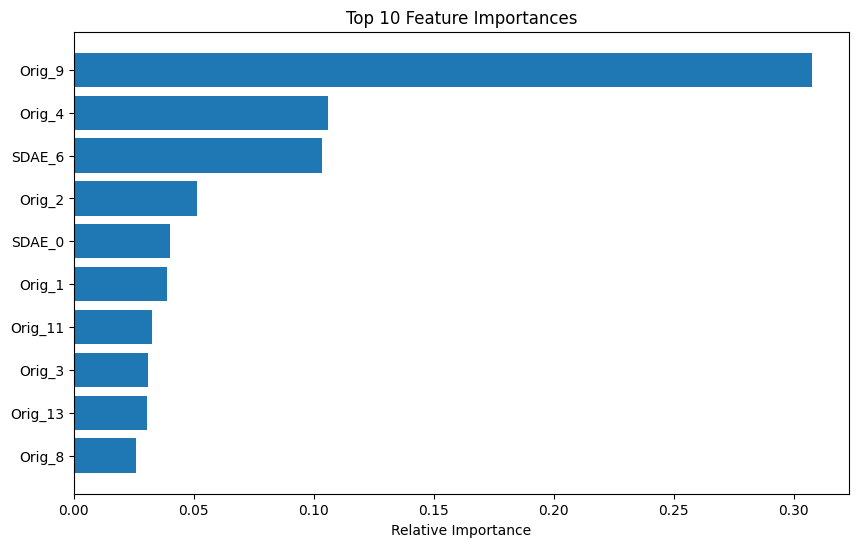

In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, f1_score
from xgboost import XGBClassifier
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# 1. 数据准备 (假设 X_train, y_train, X_test, y_test 已存在)
# ==========================================
# 确保数据是归一化的，这对 SDAE 至关重要
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"原始数据维度: {X_train_scaled.shape}")

# ==========================================
# 2. 训练 SDAE 并提取关键特征
# ==========================================
input_dim = X_train_scaled.shape[1]
# 设计更深的漏斗结构，最后一层作为“瓶颈”
layer_dims = [input_dim, 24, 16, 8]  # 最终压缩到 8 维
encoders = []
trained_models = []

current_input = X_train_scaled
current_val = X_test_scaled # 仅用于监控 Loss，不用于训练

print("\n=== 开始 SDAE 逐层预训练 (优化版: 加入 BN) ===")

input_dim = X_train_scaled.shape[1]
layer_dims = [input_dim, 24, 16, 8]
encoders = []
trained_models = []

current_input = X_train_scaled
current_val = X_test_scaled

for i in range(len(layer_dims) - 1):
    in_dim = layer_dims[i]
    out_dim = layer_dims[i+1]
    
    print(f"Training Layer {i+1}: {in_dim} -> {out_dim}")
    
    # --- 构建更稳定的 Autoencoder ---
    input_layer = Input(shape=(in_dim,))
    
    # 1. 编码器部分 (Encoder)
    # 结构: Input -> Dropout -> Dense -> BatchNormalization -> Activation
    e = Dropout(0.1)(input_layer)
    e = Dense(out_dim, use_bias=False)(e) # 使用 BN 时通常不需要 bias
    e = BatchNormalization()(e)           # <--- 关键修改：标准化输出
    encoded = Activation('relu')(e)
    
    # 2. 解码器部分 (Decoder)
    # 注意：如果上一层是 BN+ReLU，输入近似正态分布但截断了负值。
    # 为了重构简单，解码器通常不需要太复杂，也不需要 BN
    if i == 0:
        # 第一层必须还原到 [0, 1]，使用 sigmoid
        decoded = Dense(in_dim, activation='sigmoid')(encoded)
    else:
        # 后续层还原到 BN 后的分布 (ReLU 输出)，使用 relu
        decoded = Dense(in_dim, activation='relu')(encoded)
    
    # 模型定义
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)
    
    autoencoder.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    
    # 训练
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    
    history = autoencoder.fit(
        current_input, current_input,
        epochs=60, # 稍微增加轮数，BN 有时需要多一点时间收敛
        batch_size=128, # 稍微增大 batch size 让 BN 更准确
        shuffle=True,
        validation_data=(current_val, current_val),
        callbacks=[es],
        verbose=0
    )
    
    final_loss = history.history['val_loss'][-1]
    print(f"  > Loss: {final_loss:.5f}")
    
    # 保存
    encoders.append(encoder)
    trained_models.append(autoencoder)
    
    # 更新输入
    current_input = encoder.predict(current_input, verbose=0)
    current_val = encoder.predict(current_val, verbose=0)

print("=== SDAE 训练完成 ===")


# ==========================================
# 3. 构建增强特征集 (The "Magic" Step)
# ==========================================

def get_augmented_features(X_original, trained_encoders, first_autoencoder):
    """
    生成三部分特征：
    1. 原始特征
    2. 瓶颈层特征 (Deep Features)
    3. 重构误差 (Anomaly Score)
    """
    # 1. 原始特征
    features = [X_original]
    
    # 2. 逐层传递，获取最后一层的输出 (瓶颈特征)
    curr = X_original
    for enc in trained_encoders:
        curr = enc.predict(curr, verbose=0)
    features.append(curr) # 只添加最后一次的压缩特征，避免多重共线性
    
    # 3. 计算第一层的重构误差 (Reconstruction Error)
    # 逻辑：有些流失用户在原始特征空间中可能是“异常值”，SDAE 难以还原他们
    reconstructed = first_autoencoder.predict(X_original, verbose=0)
    mse = np.mean(np.power(X_original - reconstructed, 2), axis=1)
    features.append(mse.reshape(-1, 1))
    
    return np.concatenate(features, axis=1)

print("\n正在构建增强特征集...")
X_train_aug = get_augmented_features(X_train_scaled, encoders, trained_models[0])
X_test_aug = get_augmented_features(X_test_scaled, encoders, trained_models[0])

print(f"增强后特征维度: {X_train_aug.shape} (原始={input_dim} + 瓶颈={layer_dims[-1]} + 误差=1)")

# ==========================================
# 4. 使用 XGBoost 进行最终分类
# ==========================================
print("\n=== 训练 XGBoost 分类器 ===")

# 计算正负样本比例，用于处理不平衡
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"正负样本权重比例 (scale_pos_weight): {scale_pos_weight:.2f}")

# XGBoost 参数调优 (针对增强后的特征)
# 注意：因为加了新特征，我们需要增加正则化防止过拟合
xgb_final = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    # --- 修正点：将评估指标和早停参数移到这里 ---
    eval_metric="auc",           
    early_stopping_rounds=100    
)

# 训练 (fit 中不再传递 eval_metric)
xgb_final.fit(
    X_train_aug, y_train,
    eval_set=[(X_test_aug, y_test)],
    verbose=100
)

# ==========================================
# 5. 最终评估
# ==========================================
print("\n=== 最终结果评估 ===")
y_pred_proba = xgb_final.predict_proba(X_test_aug)[:, 1]
final_auc = roc_auc_score(y_test, y_pred_proba)

# 寻找最佳 F1 阈值
best_thresh = 0.5
best_f1 = 0
for thresh in np.arange(0.2, 0.8, 0.05):
    y_bin = (y_pred_proba > thresh).astype(int)
    f1 = f1_score(y_test, y_bin)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_pred_class = (y_pred_proba > best_thresh).astype(int)

print(f"Model AUC: {final_auc:.5f}")
print(f"Best Threshold: {best_thresh:.2f}")
print(classification_report(y_test, y_pred_class))

# 特征重要性分析 (看看我们的新特征有没有用)
feature_names = [f"Orig_{i}" for i in range(input_dim)] + \
                [f"SDAE_{i}" for i in range(layer_dims[-1])] + \
                ["Recon_Error"]

importances = xgb_final.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

原始比例: 2.77
调整后的权重 (用于平衡 F1): 1.66

最佳 F1 阈值: 0.3798
对应的 F1 Score: 0.6524

=== 最终优化结果 (AUC: 0.86370) ===
              precision    recall  f1-score   support

           0       0.92      0.75      0.83       518
           1       0.54      0.81      0.65       187

    accuracy                           0.77       705
   macro avg       0.73      0.78      0.74       705
weighted avg       0.82      0.77      0.78       705



e:\miniconda3\envs\GradProject\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\miniconda3\envs\GradProject\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\miniconda3\envs\GradProject\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\miniconda3\envs\GradProject\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


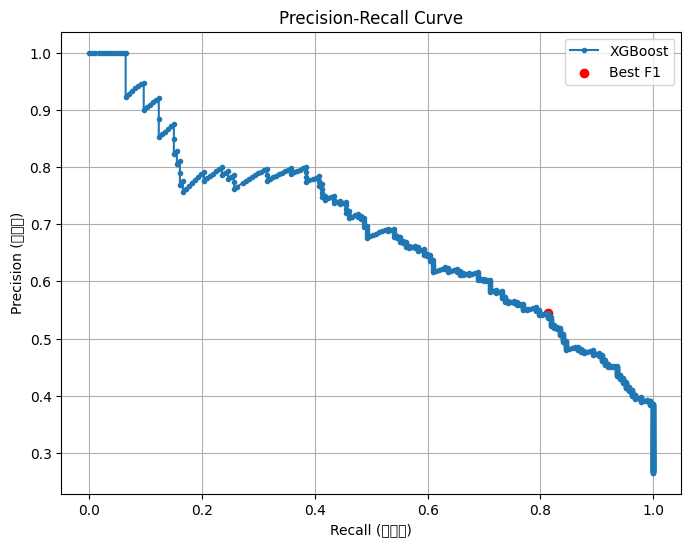

In [24]:
from sklearn.metrics import precision_recall_curve

# ==========================================
# 调整策略：降低正样本权重以提升精确率
# ==========================================

# 原始比例约为 2.77
raw_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)

# 【关键修改】使用平滑后的权重 (例如取平方根)，或者直接设置为 1.5 - 2.0 之间
# 这会让模型不再那么激进，从而提高 Precision
smooth_weight = np.sqrt(raw_ratio) 
# 或者手动指定：
# smooth_weight = 1.5 

print(f"原始比例: {raw_ratio:.2f}")
print(f"调整后的权重 (用于平衡 F1): {smooth_weight:.2f}")

xgb_final = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.2, # 稍微增加 gamma，让模型更保守，减少误判
    scale_pos_weight=smooth_weight, # <--- 修改这里
    random_state=42,
    n_jobs=-1,
    eval_metric="auc",
    early_stopping_rounds=100
)

# 训练
xgb_final.fit(
    X_train_aug, y_train,
    eval_set=[(X_test_aug, y_test)],
    verbose=0 # 保持安静
)

# ==========================================
# 精细化阈值搜索 (可视化 Precision-Recall)
# ==========================================
y_pred_proba = xgb_final.predict_proba(X_test_aug)[:, 1]

# 1. 计算最佳 F1 阈值
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh_f1 = thresholds[best_idx]
best_f1_score = f1_scores[best_idx]

print(f"\n最佳 F1 阈值: {best_thresh_f1:.4f}")
print(f"对应的 F1 Score: {best_f1_score:.4f}")

# 2. 生成最终报告
y_final_pred = (y_pred_proba > best_thresh_f1).astype(int)

print(f"\n=== 最终优化结果 (AUC: {roc_auc_score(y_test, y_pred_proba):.5f}) ===")
print(classification_report(y_test, y_final_pred))

# 3. 绘制 P-R 曲线 (帮助你决策)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, marker='.', label='XGBoost')
plt.scatter(recalls[best_idx], precisions[best_idx], marker='o', color='red', label='Best F1')
plt.xlabel('Recall (查全率)')
plt.ylabel('Precision (查准率)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


=== 梯度提升算法基准测试 (GBDT Baselines) ===
类别不平衡比例 (Majority/Minority): 2.77
XGBoost    | AUC: 0.8512 | Best F1: 0.6448 (Thresh=0.60)
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       518
           1       0.61      0.68      0.64       187

    accuracy                           0.80       705
   macro avg       0.75      0.76      0.75       705
weighted avg       0.81      0.80      0.80       705

------------------------------------------------------------
LightGBM   | AUC: 0.8454 | Best F1: 0.6392 (Thresh=0.60)
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       518
           1       0.62      0.66      0.64       187

    accuracy                           0.80       705
   macro avg       0.75      0.76      0.75       705
weighted avg       0.81      0.80      0.80       705

------------------------------------------------------------
CatBoost   | AUC: 0.8643 | Best F1: 0.6

C:\Users\lincaicai\AppData\Local\Temp\ipykernel_26076\732645038.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x='AUC', y='Model', palette='viridis')


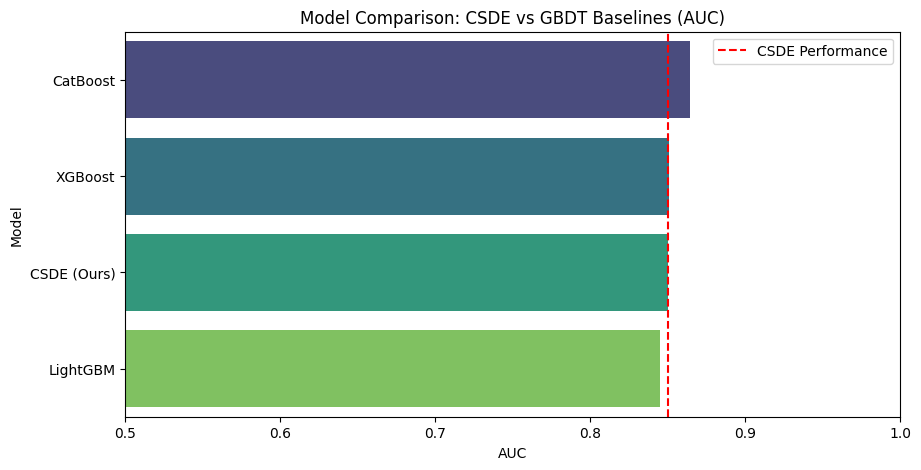


最终排行榜:
         Model       AUC        F1
2     CatBoost  0.864256  0.659574
0      XGBoost  0.851155  0.644836
3  CSDE (Ours)  0.850515  0.644068
1     LightGBM  0.845353  0.639175


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("\n=== 梯度提升算法基准测试 (GBDT Baselines) ===")

# 计算正负样本比例 (用于 XGBoost 的 scale_pos_weight)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"类别不平衡比例 (Majority/Minority): {ratio:.2f}")

# 定义模型列表
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        scale_pos_weight=ratio, # 处理不平衡的核心参数
        random_state=42,
        eval_metric='auc',
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        class_weight='balanced', # LightGBM 的平衡参数
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        auto_class_weights='Balanced', # CatBoost 的平衡参数
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
}

results = []

for name, model in models.items():
    print(f"正在训练 {name}...", end="\r")
    
    # 训练
    model.fit(X_train, y_train)
    
    # 预测
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # 评估
    auc = roc_auc_score(y_test, y_prob)
    
    # 找最佳 F1 阈值 (为了公平对比)
    best_f1 = 0
    best_t = 0.5
    for t in np.arange(0.1, 0.9, 0.05):
        pred_bin = (y_prob > t).astype(int)
        f = f1_score(y_test, pred_bin)
        if f > best_f1:
            best_f1 = f
            best_t = t
            
    y_pred = (y_prob > best_t).astype(int)
    
    # 记录结果
    print(f"{name:<10} | AUC: {auc:.4f} | Best F1: {best_f1:.4f} (Thresh={best_t:.2f})")
    print(classification_report(y_test, y_pred))
    print("-" * 60)
    
    results.append({'Model': name, 'AUC': auc, 'F1': best_f1})

# 把 CSDE 的结果也加进去对比
results.append({'Model': 'CSDE (Ours)', 'AUC': csde_auc, 'F1': f1_score(y_test, y_final_class)})

# --- 可视化对比 ---
df_res = pd.DataFrame(results).sort_values(by='AUC', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_res, x='AUC', y='Model', palette='viridis')
plt.title('Model Comparison: CSDE vs GBDT Baselines (AUC)')
plt.xlim(0.5, 1.0)
plt.axvline(x=csde_auc, color='red', linestyle='--', label='CSDE Performance')
plt.legend()
plt.show()

print("\n最终排行榜:")
print(df_res)